In [9]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add

from groq import Groq

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message

c:\Users\Loq\Documents\CRAP\end to end aibootcamp\code\handsON\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
qdrant_client=QdrantClient(url="http://localhost:6333")

In [4]:
import json
import os
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

HF_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HF_API_TOKEN = os.environ.get('HF_API_TOKEN')  # set your Hugging Face token, e.g., os.environ.get('HF_API_TOKEN')


def _mean_pool_embedding(raw_embedding):
    if not raw_embedding:
        raise ValueError("Hugging Face API returned an empty embedding.")

    if isinstance(raw_embedding[0], (int, float)):
        return [float(value) for value in raw_embedding]

    if isinstance(raw_embedding[0], list):
        token_count = len(raw_embedding)
        vector_size = len(raw_embedding[0])
        pooled = [0.0] * vector_size

        for token_vector in raw_embedding:
            if len(token_vector) != vector_size:
                raise ValueError("Inconsistent token vector dimensions in HF embedding response.")
            for idx, value in enumerate(token_vector):
                pooled[idx] += float(value)

        return [value / token_count for value in pooled]

    raise ValueError("Unexpected Hugging Face embedding response format.")


def get_embedding(text, model_name: str | None = None):
    selected_model = model_name or HF_EMBEDDING_MODEL
    endpoint = (
        "https://router.huggingface.co/hf-inference/models/"
        f"{selected_model}/pipeline/feature-extraction"
    )
    payload = json.dumps({"inputs": text, "normalize": True}).encode("utf-8")

    headers = {"Content-Type": "application/json"}
    if HF_API_TOKEN:
        headers["Authorization"] = f"Bearer {HF_API_TOKEN}"

    request = Request(endpoint, data=payload, headers=headers, method="POST")

    try:
        with urlopen(request, timeout=60) as response:
            response_data = json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        message = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(
            f"Hugging Face embedding API request failed ({exc.code}): {message}"
        ) from exc
    except URLError as exc:
        raise RuntimeError(f"Could not reach Hugging Face embedding API: {exc}") from exc

    if isinstance(response_data, dict) and response_data.get("error"):
        raise RuntimeError(f"Hugging Face embedding API error: {response_data['error']}")

    if isinstance(response_data, list) and len(response_data) == 1:
        return _mean_pool_embedding(response_data[0])

    return _mean_pool_embedding(response_data)



In [6]:
def retrieve_data(query,qdrant_client, top_k=5):

    query_embedding=get_embedding(query)

    search_result=qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="all-MiniLM-L6-v2",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=top_k,
    )

    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]
    for search_result in search_result.points:
        retrieved_context_ids.append(search_result.payload["parent_asin"])
        retrieved_context.append(search_result.payload["description"])
        retrieved_context_ratings.append(search_result.payload["average_rating"])
        similarity_scores.append(search_result.score)


    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "retrieved_context_ratings": retrieved_context_ratings,
        "similarity_scores": similarity_scores,
    }

In [7]:
query="can i get a rock album recommendation with a happy vib e?"

In [17]:
answer = retrieve_data(query,qdrant_client)

In [18]:
answer

{'retrieved_context_ids': ['B09ZLJGLBR',
  'B09WF3XKNW',
  'B0B7271P1G',
  'B0B3M8PDRX',
  'B09TN45G5Y'],
 'retrieved_context': ["Codex VI[3 LP] It's been 26 incredible years of psychedelic sound surfing with Shpongle and now we arrive at the magical 6th album, a visionary volume entitled CODEX VI. A cosmic collection of mystical music from Simon and Raja in which their elucidation of hallucination reveals once again, a seemingly effortless mastery of inter-dimensional audio. We invite you to share the inner secrets of the CODEX formulae and get a direct download of illuminated inspiration which will leave you seriously Shpongled.",
  'Unforgettable With Love - Excusive Limited Edition White Colored Vinyl 2LP Unforgettable With Love - Excusive Limited Edition White Colored Vinyl 2LP Tracklist A1. The Very Thought Of You A2. Paper Moon A3. Route 66 A4. Mona Lisa A5. L-O-V-E A6. This Can’t Be Love B1. Smile B2. Lush Life B3. That Sunday That Summer B4. Orange Colored Sky B5: A Medley Of:

#### multi intent questions

In [8]:
query="CAN i get a kids album for my kid and a rock album for me and romantic album for my wife"

In [9]:
class QueryExpandResponse(BaseModel):
    answer: List[str] = Field(..., description="List of expanded queries derived from the original query.")

In [10]:
def query_expand_node(query) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""
    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider("groq/qwen/qwen3-32b")

    response, raw_response = client.create_with_completion(
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
        reasoning_effort="default",
        reasoning_format="hidden",
    )

    return {
        "queries": response.answer
    }

In [22]:
answer=query_expand_node(query)

In [23]:
answer

{'queries': ['kids music album',
  "children's music collection",
  'rock music album',
  'best rock albums',
  'romance music album',
  'love songs collection']}

### langgraph

### query expansion sequencial execution

In [11]:
class State(BaseModel):
    expanded_query: List[str]=[]
    retrieved_context: Annotated[List[str],add]=[]  
    initial_query: str=""
    answer:str=""

#### query expansion/ rewriting node

In [12]:
class QueryExpandResponse(BaseModel):
    answer: List[str] = Field(..., description="List of expanded queries derived from the original query.")

In [13]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"qwen3-32b"}
)
def query_expand_node(state: State) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
-Be as Concise as possible , do not make synonyms, one statement per piece of context.
<Question>
{{ query }}
</Question>
"""
    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider("groq/qwen/qwen3-32b")

    response, raw_response = client.create_with_completion(
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
        reasoning_effort="default",
        reasoning_format="hidden",
    )

    return {
        "expanded_query": response.answer
    }

#### retriver node

In [14]:
import json
import os
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

HF_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HF_API_TOKEN = os.environ.get('HF_API_TOKEN')  # set your Hugging Face token, e.g., os.environ.get('HF_API_TOKEN')


def _mean_pool_embedding(raw_embedding):
    if not raw_embedding:
        raise ValueError("Hugging Face API returned an empty embedding.")

    if isinstance(raw_embedding[0], (int, float)):
        return [float(value) for value in raw_embedding]

    if isinstance(raw_embedding[0], list):
        token_count = len(raw_embedding)
        vector_size = len(raw_embedding[0])
        pooled = [0.0] * vector_size

        for token_vector in raw_embedding:
            if len(token_vector) != vector_size:
                raise ValueError("Inconsistent token vector dimensions in HF embedding response.")
            for idx, value in enumerate(token_vector):
                pooled[idx] += float(value)

        return [value / token_count for value in pooled]

    raise ValueError("Unexpected Hugging Face embedding response format.")

@traceable(name="embed query",run_type="embedding",metadata={"ls_provider":"hugging-face","ls_model_name":"sentence-transformers/all-MiniLM-L6-v2"})
def get_embedding(text, model_name: str | None = None):
    selected_model = model_name or HF_EMBEDDING_MODEL
    endpoint = (
        "https://router.huggingface.co/hf-inference/models/"
        f"{selected_model}/pipeline/feature-extraction"
    )
    payload = json.dumps({"inputs": text, "normalize": True}).encode("utf-8")

    headers = {"Content-Type": "application/json"}
    if HF_API_TOKEN:
        headers["Authorization"] = f"Bearer {HF_API_TOKEN}"

    request = Request(endpoint, data=payload, headers=headers, method="POST")

    try:
        with urlopen(request, timeout=60) as response:
            response_data = json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        message = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(
            f"Hugging Face embedding API request failed ({exc.code}): {message}"
        ) from exc
    except URLError as exc:
        raise RuntimeError(f"Could not reach Hugging Face embedding API: {exc}") from exc

    if isinstance(response_data, dict) and response_data.get("error"):
        raise RuntimeError(f"Hugging Face embedding API error: {response_data['error']}")

    if isinstance(response_data, list) and len(response_data) == 1:
        return _mean_pool_embedding(response_data[0])

    return _mean_pool_embedding(response_data)



@traceable(name="retrieve data",run_type="retriever")
def retrieve_data(query, top_k=5):
    qdrant_client=QdrantClient(url="http://localhost:6333")

    query_embedding=get_embedding(query)

    search_result=qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="all-MiniLM-L6-v2",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=top_k,
    )

    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]
    for search_result in search_result.points:
        retrieved_context_ids.append(search_result.payload["parent_asin"])
        retrieved_context.append(search_result.payload["description"])
        retrieved_context_ratings.append(search_result.payload["average_rating"])
        similarity_scores.append(search_result.score)

    formatted_context=""
    for id , chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context+=f"-ID: {id},rating: {rating},description: {chunk} \n"


    return formatted_context

@traceable(name="retrieve node",run_type="retriever")
def retriever_node(state: State) -> dict:

    retrieved_context=[]
    
    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query))

    return {
        "retrieved_context": retrieved_context
    } 


#### aggregator node

In [15]:
#### aggregator node to combine retrieved contexts
class AggregatorResponse(BaseModel):
    answer: str = Field(..., description="Final answer generated by the aggregator node based on the retrieved contexts.")

In [16]:
@traceable(
        name="aggregator_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"qwen3-32b"}
)
def aggregator_node(state: State) -> dict:
    preprocessed_context="\n".join(state.retrieved_context),
    prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    Instructions:
    
    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.
    
    Context:
    {{ preprocessed_context }}

    Question:
    {{ question }}
"""
    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider("groq/qwen/qwen3-32b")

    response, raw_response = client.create_with_completion(
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
        reasoning_effort="default",
        reasoning_format="hidden",
    )

    return {
        "answer": response.answer
    }

In [17]:
workflow = StateGraph(State)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph=workflow.compile()

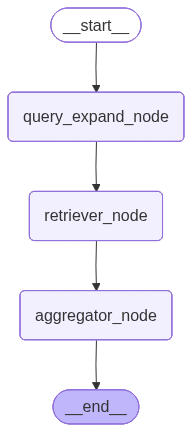

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
initial_state = {
    "initial_query": "CAN i get a kids album for my kid and a rock album for me and romantic album for my wife"
}


In [47]:
result = graph.invoke(initial_state)

In [48]:
result

{'expanded_query': ['kids album for kid',
  'rock album for me',
  'romantic album for wife'],
 'retrieved_context': ['-ID: B0C2B869LV,rating: 4.6,description: Rise And Fall, Rage And Grace [15th Anniversary Edition] [LP + 7" Single] 15th Anniversary Edition of The Offspring\'s 2008 album - Rise And Fall, Rage And Grace - featuring a bonus 7" single on translucent red vinyl with two new live tracks from Hellfest, a newly reimagined album cover and art lithographs for each song. The album and 7" single includes their most popular streaming song, "You\'re Gonna Go Far, Kid." Limited Edition. \n-ID: B09RBK5PX3,rating: 4.7,description: Gold Rush Kid Gold Rush Kid is the highly anticipated new album from singer-songwriter George Ezra. This 12 track album was announced with the release of the first single and video, ‘Anyone For You.’ In speaking about the lead single, George says: “‘Anyone For You’ is a patchwork of lyric ideas found in old notebooks and chance moments shared between musicia

#### query expansion(parallel execution)

In [11]:
class State(BaseModel):
    expanded_query: List[str]=[]
    retrieved_context: Annotated[List[str],add]=[]  
    initial_query: str=""
    answer:str=""
    query:str=""
    k:int=20

#### query expansion/rewriting node

In [12]:
class QueryExpandResponse(BaseModel):
    expanded_query: List[str] = Field(..., description="List of expanded queries derived from the original query.")

In [13]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"qwen3-32b"}
)
def query_expand_node(state: State) -> dict:

    prompt_template = """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
-Be as Concise as possible , do not make synonyms, one statement per piece of context.
<Question>
{{ query }}
</Question>
"""
    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider("groq/qwen/qwen3-32b")

    response, raw_response = client.create_with_completion(
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
        reasoning_effort="default",
        reasoning_format="hidden",
    )

    return {
        "expanded_query": response.expanded_query
    }

In [14]:
def query_expand_conditional_edges(state: State):
    send_messages = []
    
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )
    
    return send_messages

In [15]:
import json
import os
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

HF_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
HF_API_TOKEN = os.environ.get('HF_API_TOKEN')  # set your Hugging Face token, e.g., os.environ.get('HF_API_TOKEN')


def _mean_pool_embedding(raw_embedding):
    if not raw_embedding:
        raise ValueError("Hugging Face API returned an empty embedding.")

    if isinstance(raw_embedding[0], (int, float)):
        return [float(value) for value in raw_embedding]

    if isinstance(raw_embedding[0], list):
        token_count = len(raw_embedding)
        vector_size = len(raw_embedding[0])
        pooled = [0.0] * vector_size

        for token_vector in raw_embedding:
            if len(token_vector) != vector_size:
                raise ValueError("Inconsistent token vector dimensions in HF embedding response.")
            for idx, value in enumerate(token_vector):
                pooled[idx] += float(value)

        return [value / token_count for value in pooled]

    raise ValueError("Unexpected Hugging Face embedding response format.")

@traceable(name="embed query",run_type="embedding",metadata={"ls_provider":"hugging-face","ls_model_name":"sentence-transformers/all-MiniLM-L6-v2"})
def get_embedding(text, model_name: str | None = None):
    selected_model = model_name or HF_EMBEDDING_MODEL
    endpoint = (
        "https://router.huggingface.co/hf-inference/models/"
        f"{selected_model}/pipeline/feature-extraction"
    )
    payload = json.dumps({"inputs": text, "normalize": True}).encode("utf-8")

    headers = {"Content-Type": "application/json"}
    if HF_API_TOKEN:
        headers["Authorization"] = f"Bearer {HF_API_TOKEN}"

    request = Request(endpoint, data=payload, headers=headers, method="POST")

    try:
        with urlopen(request, timeout=60) as response:
            response_data = json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        message = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(
            f"Hugging Face embedding API request failed ({exc.code}): {message}"
        ) from exc
    except URLError as exc:
        raise RuntimeError(f"Could not reach Hugging Face embedding API: {exc}") from exc

    if isinstance(response_data, dict) and response_data.get("error"):
        raise RuntimeError(f"Hugging Face embedding API error: {response_data['error']}")

    if isinstance(response_data, list) and len(response_data) == 1:
        return _mean_pool_embedding(response_data[0])

    return _mean_pool_embedding(response_data)



@traceable(name="retrieve data",run_type="retriever")
def retrieve_node(state: State) -> dict:
    qdrant_client=QdrantClient(url="http://localhost:6333")

    query_embedding=get_embedding(state["query"])

    search_result=qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="all-MiniLM-L6-v2",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state["query"],
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=state["k"],
    )

    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]
    for search_result in search_result.points:
        retrieved_context_ids.append(search_result.payload["parent_asin"])
        retrieved_context.append(search_result.payload["description"])
        retrieved_context_ratings.append(search_result.payload["average_rating"])
        similarity_scores.append(search_result.score)

    formatted_context=""
    for id , chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context+=f"-ID: {id},rating: {rating},description: {chunk} \n"


    return {
        "retrieved_context": [formatted_context]
    }


In [16]:
#### aggregator node to combine retrieved contexts
class AggregatorResponse(BaseModel):
    answer: str = Field(..., description="Final answer generated by the aggregator node based on the retrieved contexts.")

In [33]:
@traceable(
        name="aggregator_node",
        run_type="llm",
        metadata={"ls_provider":"groq","ls_model_name":"llama-3.3-70b-versatile"}
)
def aggregator_node(state: State) -> dict:
    preprocessed_context="\n".join(state.retrieved_context)
    prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    Instructions:
    
    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.
    
    Context:
    {{ preprocessed_context }}

    Question:
    {{ question }}
"""
    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider("groq/llama-3.3-70b-versatile")

    response, raw_response = client.create_with_completion(
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
    )

    return {
        "answer": response.answer
    }

In [34]:
workflow = StateGraph(State)
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)

workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph=workflow.compile()

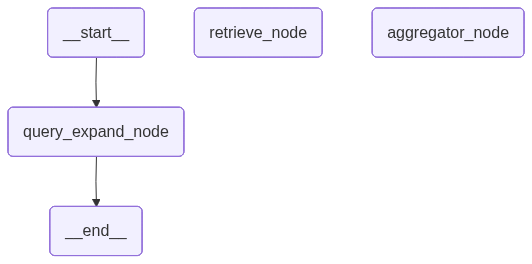

In [35]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
initial_state = {
    "initial_query": "CAN i get a kids album for my kid and a rock album for me and romantic album for my wife"
}


In [37]:
result = graph.invoke(initial_state)

In [38]:
result

{'expanded_query': ['kids album for my kid',
  'rock album for me',
  'romantic album for my wife'],
 'retrieved_context': ['-ID: B0C2B869LV,rating: 4.6,description: Rise And Fall, Rage And Grace [15th Anniversary Edition] [LP + 7" Single] 15th Anniversary Edition of The Offspring\'s 2008 album - Rise And Fall, Rage And Grace - featuring a bonus 7" single on translucent red vinyl with two new live tracks from Hellfest, a newly reimagined album cover and art lithographs for each song. The album and 7" single includes their most popular streaming song, "You\'re Gonna Go Far, Kid." Limited Edition. \n-ID: B09RBK5PX3,rating: 4.7,description: Gold Rush Kid Gold Rush Kid is the highly anticipated new album from singer-songwriter George Ezra. This 12 track album was announced with the release of the first single and video, ‘Anyone For You.’ In speaking about the lead single, George says: “‘Anyone For You’ is a patchwork of lyric ideas found in old notebooks and chance moments shared between m